# Assamese NER Dataset Analysis (Naamapadam)

In this notebook, we will analyze the assamese portion of the **Naamapadam dataset**.  
The dataset is for **Named Entity Recognition (NER)**, which means the task is to identify and classify named entities like person names, locations, organizations, etc.  

In this step, we loaded the Naamapadam Telugu dataset using HuggingFace datasets library.
It contains three splits: Train, Validation, and Test.
These splits will be used for model training, hyperparameter tuning, and evaluation.

In [ ]:
!pip install -q datasets==2.14.5 seaborn wordcloud scipy

from datasets import load_dataset
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter, defaultdict
from tqdm.auto import tqdm
import json, unicodedata, itertools
from scipy.stats import wasserstein_distance, entropy, ttest_ind
from math import sqrt
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 8.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.6.0 which is incompatible.


###  Load Assamese dataset
We load the HuggingFace `ai4bharat/naamapadam` dataset with the "te" config (Telugu).


In [ ]:
# Assamese dataset
ds_as = load_dataset("ai4bharat/naamapadam", "as")
print(ds_as)
print(ds_as["train"][0])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 10266
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 51
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 52
    })
})
{'tokens': ['কিন্তু', 'বিচাৰি', 'পায়', 'ক', "'", 'ত', '?'], 'ner_tags': [0, 0, 0, 0, 0, 0, 0]}


###  Convert to DataFrame
For better data analysis, we convert the dataset into a pandas DataFrame.  
This allows us to easily check sentence lengths, entity distribution, and perform statistics.


In [ ]:
df_as = pd.DataFrame(ds_as["train"])
df_as.head()


,tokens,ner_tags
0,"[কিন্তু, বিচাৰি, পায়, ক, ', ত, ?]","[0, 0, 0, 0, 0, 0, 0]"
1,"[আলেখ্য, সম্পাদক]","[0, 0]"
2,"[এটা, VPN, সংযোগ, ধৰণ, বাছক]","[0, 0, 0, 0, 0]"
3,"[এটা, সেৱাক, &, brandShortName, ., লৈ, যোগ, কৰ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
4,"["", এই, কি, ', য়ে, সন্ধান, সঁজুলি, আৰম্ভ, হওত...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


###  Dataset Statistics
- We calculate:
  - Number of sentences in train, validation, test.
  - Average sentence length (in words).
- This helps us understand how large and balanced the dataset is.


In [ ]:
print("Number of sentences:", len(df_as))
print("Columns:", df_as.columns)
df_as.info()


Number of sentences: 10266
Columns: Index(['tokens', 'ner_tags'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10266 entries, 0 to 10265
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   tokens    10266 non-null  object
 1   ner_tags  10266 non-null  object
dtypes: object(2)
memory usage: 160.5+ KB


#  Sentence Lengths
The majority of sentences are relatively short.  
- Sentence lengths peak around **15–25 tokens**.  
- The maximum observed length is **100 tokens**.  
The distribution looks similar across train, validation, and test splits.


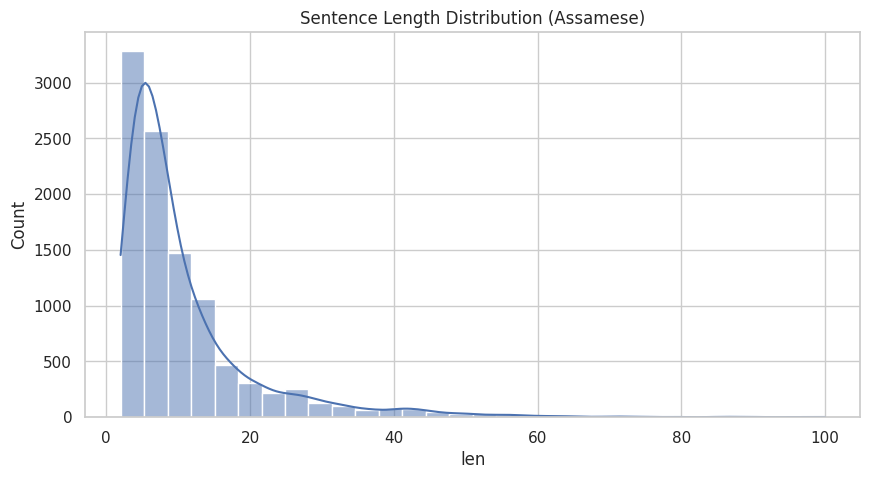

In [ ]:
df_as["len"] = df_as["tokens"].apply(len)
sns.histplot(df_as["len"], bins=30, kde=True)
plt.title("Sentence Length Distribution (Assamese)")
plt.show()


In [ ]:
for i in range(3):
    print("Tokens:", df_as["tokens"][i])
    print("NER Tags:", df_as["ner_tags"][i])
    print()


Tokens: ['কিন্তু', 'বিচাৰি', 'পায়', 'ক', "'", 'ত', '?']
NER Tags: [0, 0, 0, 0, 0, 0, 0]

Tokens: ['আলেখ্য', 'সম্পাদক']
NER Tags: [0, 0]

Tokens: ['এটা', 'VPN', 'সংযোগ', 'ধৰণ', 'বাছক']
NER Tags: [0, 0, 0, 0, 0]



In [ ]:
id2label = ds_as["train"].features["ner_tags"].feature.int2str
df_as["ner_tags_str"] = df_as["ner_tags"].apply(lambda x: [id2label(i) for i in x])
df_as.head()


,tokens,ner_tags,len,ner_tags_str
0,"[কিন্তু, বিচাৰি, পায়, ক, ', ত, ?]","[0, 0, 0, 0, 0, 0, 0]",7,"[O, O, O, O, O, O, O]"
1,"[আলেখ্য, সম্পাদক]","[0, 0]",2,"[O, O]"
2,"[এটা, VPN, সংযোগ, ধৰণ, বাছক]","[0, 0, 0, 0, 0]",5,"[O, O, O, O, O]"
3,"[এটা, সেৱাক, &, brandShortName, ., লৈ, যোগ, কৰ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",12,"[O, O, O, O, O, O, O, O, O, O, O, O]"
4,"["", এই, কি, ', য়ে, সন্ধান, সঁজুলি, আৰম্ভ, হওত...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",24,"[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."


### Entity Tag Distribution
We check how many times each entity label appears in the training data.  
This gives insights into:
- Whether the dataset is balanced.
- Which entities are most common (e.g., **PERSON** may appear more than **ORGANIZATION**).


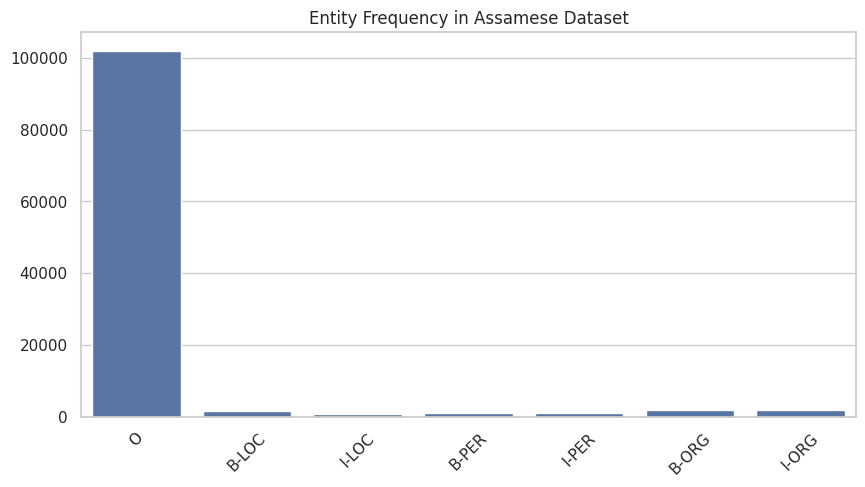

In [ ]:
all_entities = list(itertools.chain.from_iterable(df_as["ner_tags_str"]))
freq_entities = Counter(all_entities)
sns.barplot(x=list(freq_entities.keys()), y=list(freq_entities.values()))
plt.title("Entity Frequency in Assamese Dataset")
plt.xticks(rotation=45)
plt.show()


In [ ]:
all_tokens = list(itertools.chain.from_iterable(df_as["tokens"]))
freq_tokens = Counter(all_tokens).most_common(20)
pd.DataFrame(freq_tokens, columns=["Token", "Count"])


,Token,Count
0,।,6550
1,",",3280
2,',1823
3,আৰু,1757
4,"""",1634
5,-,1491
6,এটা,1275
7,কৰা,1207
8,কৰক,949
9,এই,910


In [ ]:
entities_with_tokens = []
for tokens, tags in zip(df_as["tokens"], df_as["ner_tags_str"]):
    for t, tag in zip(tokens, tags):
        if tag != "O":
            entities_with_tokens.append((t, tag))

pd.DataFrame(entities_with_tokens, columns=["Token", "Entity"]).head(20)


,Token,Entity
0,টাইগ্ৰিছ,B-LOC
1,ইউফ্ৰেটিছ,B-LOC
2,দক্ষিণলৈ,B-LOC
3,পাৰ্ছিয়ান,I-LOC
4,ছাট,B-LOC
5,আল,I-LOC
6,-,I-LOC
7,আৰৱলৈ,I-LOC
8,পণ্ডিত,B-PER
9,দীনদয়াল,I-PER


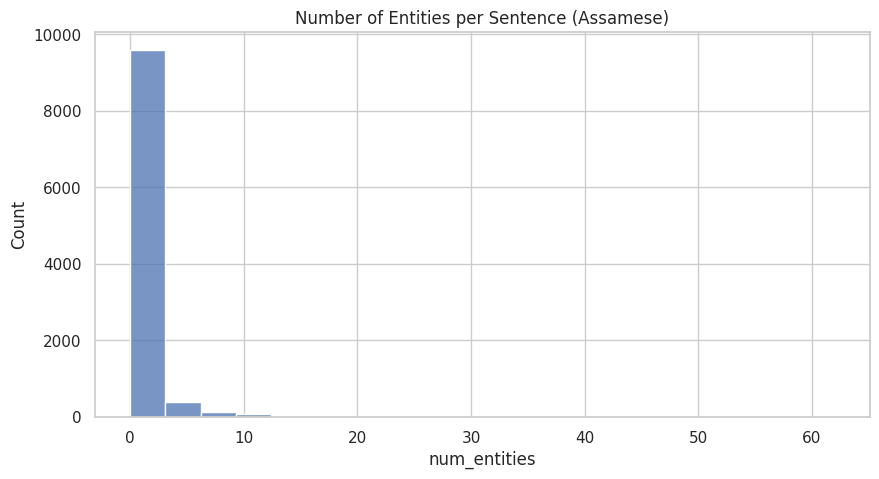

In [ ]:
df_as["num_entities"] = df_as["ner_tags_str"].apply(lambda x: sum(tag != "O" for tag in x))
sns.histplot(df_as["num_entities"], bins=20, kde=False)
plt.title("Number of Entities per Sentence (Assamese)")
plt.show()


In [ ]:
top_entities = Counter([t for t, tag in entities_with_tokens]).most_common(20)
pd.DataFrame(top_entities, columns=["Entity", "Count"])


,Entity,Count
0,আৰু,124
1,",",120
2,নৰেন্দ্ৰ,97
3,GNOME,94
4,-,78
5,',65
6,SSL,65
7,মোদীয়ে,48
8,শ্ৰী,43
9,অসম,37


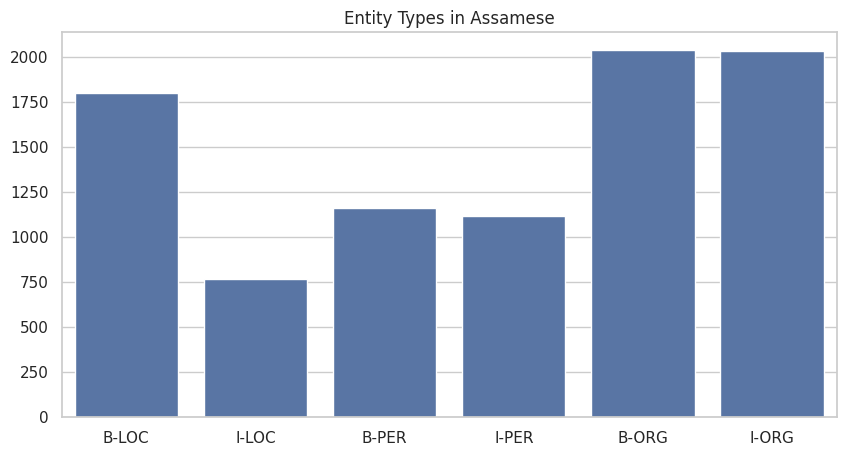

In [ ]:
entity_type_counts = Counter([tag for _, tag in entities_with_tokens])
sns.barplot(x=list(entity_type_counts.keys()), y=list(entity_type_counts.values()))
plt.title("Entity Types in Assamese")
plt.show()


In [ ]:
i = np.random.randint(len(df_as))
tokens, tags = df_as["tokens"][i], df_as["ner_tags_str"][i]
for t, tag in zip(tokens, tags):
    print(f"{t:15} -> {tag}")


বিগত            -> O
কিছুদিন         -> O
দি              -> O
থকা             -> O
নেৰা            -> O
নেপেৰা          -> O
বৰষুণৰ          -> O
ফলত             -> O
জমা             -> O
হোৱা            -> O
পানীয়ে         -> O
এই              -> O
বানৰ            -> O
সৃষ্টি          -> O
কৰিছে           -> O
।               -> O


In [ ]:
df_as.to_csv("assamese_ner_processed.csv", index=False)
print("Saved processed Assamese dataset ✅")


Saved processed Assamese dataset ✅


In [ ]:
print(ds_as)

for split in ds_as.keys():
    print(f"{split} size: {len(ds_as[split])}")


DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 10266
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 51
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 52
    })
})
train size: 10266
test size: 51
validation size: 52


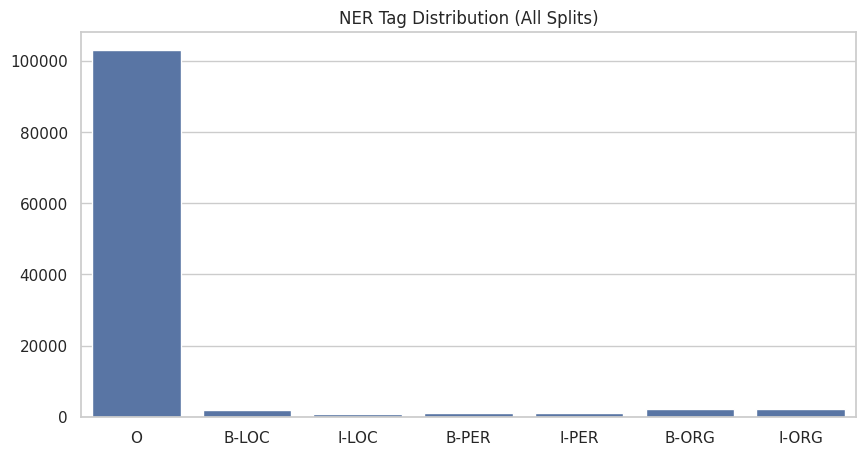

In [ ]:
# Flatten all tags across splits
all_tags = []
for split in ds_as.keys():
    for row in ds_as[split]["ner_tags"]:
        all_tags.extend(row)

tag_counts = Counter(all_tags)
tag_names = [ds_as["train"].features["ner_tags"].feature.int2str(i) for i in tag_counts.keys()]

sns.barplot(x=tag_names, y=list(tag_counts.values()))
plt.title("NER Tag Distribution (All Splits)")
plt.show()


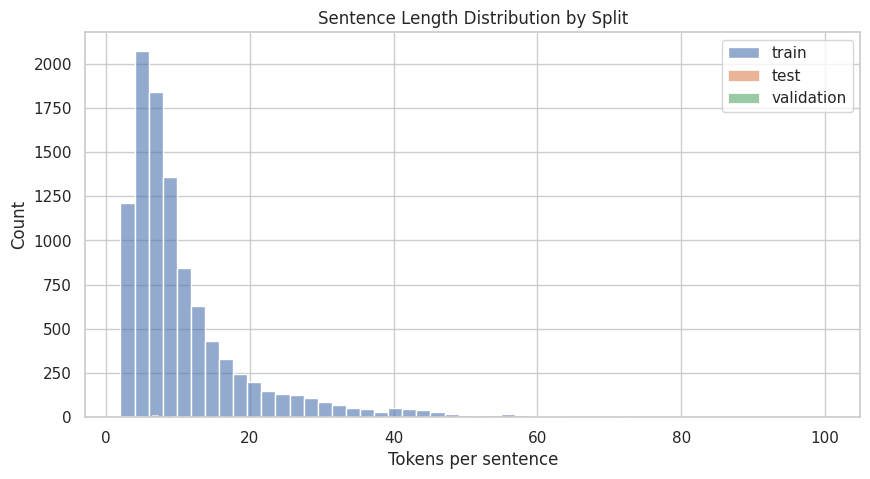

Max sequence length: 100


In [ ]:
for split in ds_as.keys():
    lengths = [len(x) for x in ds_as[split]["tokens"]]
    sns.histplot(lengths, bins=50, kde=False, label=split, alpha=0.6)

plt.legend()
plt.title("Sentence Length Distribution by Split")
plt.xlabel("Tokens per sentence")
plt.ylabel("Count")
plt.show()

print("Max sequence length:", max(len(x) for x in ds_as["train"]["tokens"]))


Sentences with at least one PER tag: 7.51 %


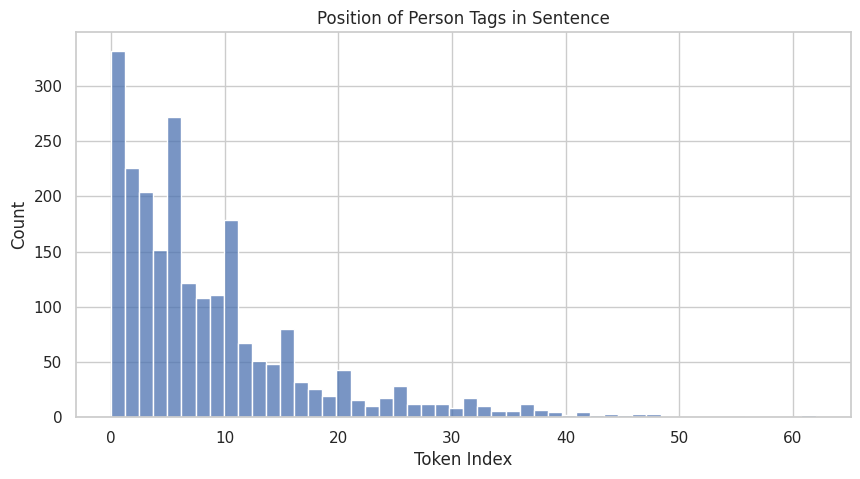

In [ ]:
def contains_person(tags):
    return any(t in [ds_as["train"].features["ner_tags"].feature.str2int("B-PER"),
                     ds_as["train"].features["ner_tags"].feature.str2int("I-PER")] for t in tags)

person_sents = sum(contains_person(tags) for tags in ds_as["train"]["ner_tags"])
print("Sentences with at least one PER tag:", round(person_sents/len(ds_as["train"])*100, 2), "%")

# Where PER occurs in sentences
positions = []
for tokens, tags in zip(ds_as["train"]["tokens"], ds_as["train"]["ner_tags"]):
    for idx, t in enumerate(tags):
        if ds_as["train"].features["ner_tags"].feature.int2str(t) in ["B-PER","I-PER"]:
            positions.append(idx)

sns.histplot(positions, bins=50)
plt.title("Position of Person Tags in Sentence")
plt.xlabel("Token Index")
plt.show()


In [ ]:
co_counts = defaultdict(int)

for tags in ds_as["train"]["ner_tags"]:
    tag_strs = set([ds_as["train"].features["ner_tags"].feature.int2str(t) for t in tags])
    if any("LOC" in t for t in tag_strs):
        for t in tag_strs:
            if t != "O":
                co_counts[t] += 1

pd.DataFrame.from_dict(co_counts, orient="index", columns=["Co-occurrence with LOC"])


,Co-occurrence with LOC
B-LOC,863
I-LOC,253
B-ORG,199
B-PER,172
I-ORG,121
I-PER,114


In [ ]:
bio_counts = defaultdict(lambda: {"B":0,"I":0})

for tags in ds_as["train"]["ner_tags"]:
    for t in tags:
        tag = ds_as["train"].features["ner_tags"].feature.int2str(t)
        if tag != "O":
            prefix, ent = tag.split("-")
            bio_counts[ent][prefix] += 1

ratios = {ent: (bio_counts[ent]["I"]/bio_counts[ent]["B"] if bio_counts[ent]["B"]>0 else 0)
          for ent in bio_counts}

print("BIO Ratios (I/B):", ratios)


BIO Ratios (I/B): {'LOC': 0.424680377987771, 'PER': 0.9611734253666955, 'ORG': 0.9965635738831615}


/tmp/ipython-input-4063637672.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([entity_lengths[e] for e in entity_lengths], labels=entity_lengths.keys())


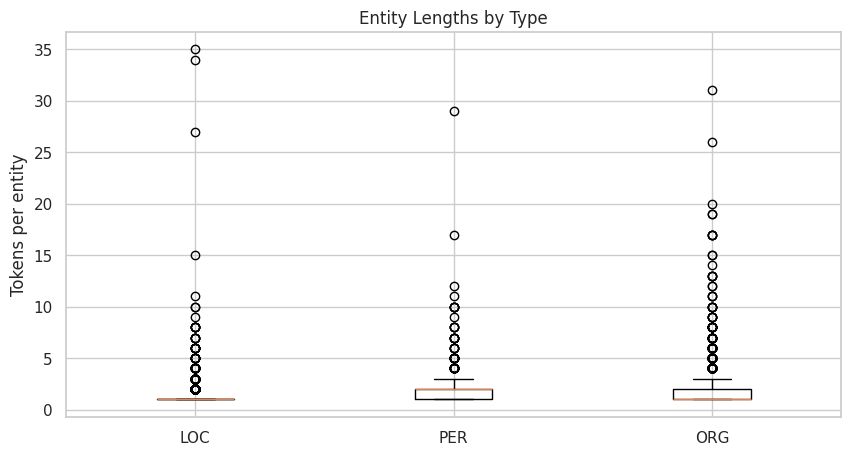

In [ ]:
entity_lengths = defaultdict(list)

for tokens, tags in zip(ds_as["train"]["tokens"], ds_as["train"]["ner_tags"]):
    current_ent, length = None, 0
    for t, tag_id in zip(tokens, tags):
        tag = ds_as["train"].features["ner_tags"].feature.int2str(tag_id)
        if tag == "O":
            if current_ent:
                entity_lengths[current_ent].append(length)
                current_ent, length = None, 0
        else:
            prefix, ent = tag.split("-")
            if prefix == "B":
                if current_ent:
                    entity_lengths[current_ent].append(length)
                current_ent, length = ent, 1
            else:  # I
                if current_ent == ent:
                    length += 1
                else:
                    current_ent, length = ent, 1
    if current_ent:
        entity_lengths[current_ent].append(length)

# Boxplot
plt.boxplot([entity_lengths[e] for e in entity_lengths], labels=entity_lengths.keys())
plt.title("Entity Lengths by Type")
plt.ylabel("Tokens per entity")
plt.show()


In [ ]:
def generate_summary(ds):
    # --- Dataset size ---
    sizes = {split: len(ds[split]) for split in ds.keys()}

    # --- Tag distribution ---
    all_tags = []
    for split in ds.keys():
        for row in ds[split]["ner_tags"]:
            all_tags.extend(row)
    tag_counts = Counter(all_tags)
    feature = ds["train"].features["ner_tags"].feature
    tag_names = {i: feature.int2str(i) for i in tag_counts.keys()}
    most_common = sorted([(tag_names[i], c) for i,c in tag_counts.items()], key=lambda x:-x[1])[:5]

    # --- Sentence length ---
    lengths = [len(x) for x in ds["train"]["tokens"]]
    avg_len = sum(lengths)/len(lengths)
    max_len = max(lengths)

    # --- Person tag %
    def contains_person(tags):
        return any(t in [feature.str2int("B-PER"), feature.str2int("I-PER")] for t in tags)
    person_sents = sum(contains_person(tags) for tags in ds["train"]["ner_tags"])
    person_ratio = round(person_sents/len(ds["train"])*100, 2)

    # --- BIO Ratios ---
    bio_counts = defaultdict(lambda: {"B":0,"I":0})
    for tags in ds["train"]["ner_tags"]:
        for t in tags:
            tag = feature.int2str(t)
            if tag != "O":
                prefix, ent = tag.split("-")
                bio_counts[ent][prefix] += 1
    ratios = {ent: round(bio_counts[ent]["I"]/bio_counts[ent]["B"],2) if bio_counts[ent]["B"]>0 else 0
              for ent in bio_counts}

    # --- Final text summary ---
    summary = f"""
    Dataset Summary:
    - Train/Validation/Test sizes: {sizes}
    - Most common tags: {most_common}
    - Sentence length: average {avg_len:.1f}, max {max_len}
    - Sentences with PER: {person_ratio}%
    - BIO Ratios (I/B): {ratios}
    Overall, 'O' is the dominant tag. PER and ORG entities are frequent, ORG names tend to be longer,
    while LOC entities are shorter.
    """
    return summary


In [ ]:
summary_text = generate_summary(ds_as)
print(summary_text)



    Dataset Summary:
    - Train/Validation/Test sizes: {'train': 10266, 'test': 51, 'validation': 52}
    - Most common tags: [('O', 102992), ('I-ORG', 2116), ('B-ORG', 2066), ('B-LOC', 1811), ('B-PER', 1168)]
    - Sentence length: average 10.8, max 100
    - Sentences with PER: 7.51%
    - BIO Ratios (I/B): {'LOC': 0.42, 'PER': 0.96, 'ORG': 1.0}
    Overall, 'O' is the dominant tag. PER and ORG entities are frequent, ORG names tend to be longer, 
    while LOC entities are shorter.
    
